In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")
RAW = Path("../data/raw")
REPORTS = Path("../reports")
REPORTS.mkdir(exist_ok=True)

print("✅ Libraries loaded!")

✅ Libraries loaded!


Task was destroyed but it is pending!
task: <Task pending name='Task-106' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\gopiu\AppData\Roaming\Python\Python314\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-107' coro=<Kernel.shell_main() running at C:\Users\gopiu\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\gopiu\AppData\Roaming\Python\Python314\site-packages\zmq\eventloop\zmqstream.py:563]>
<frozen _collections_abc>:115: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
Task was destroyed but it is pending!
task: <Task pending name='Task-107' coro=<Kernel.shell_main() running at C:\Users\gopiu\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


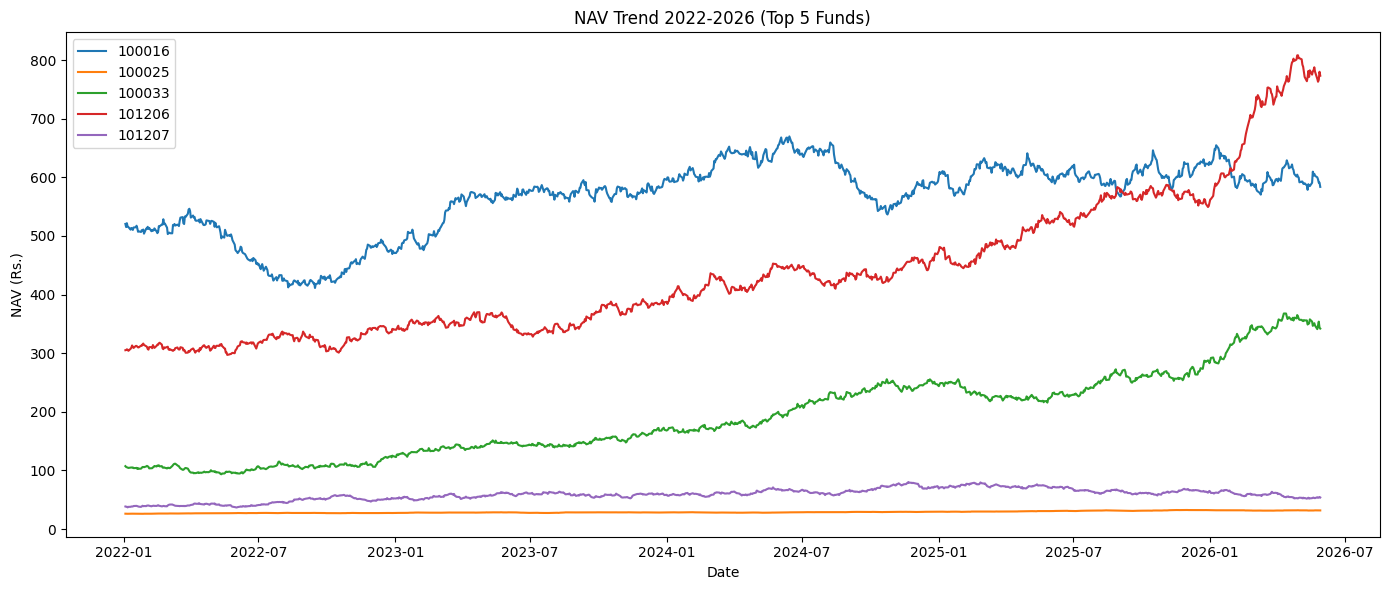

✅ Chart 1 done!


In [6]:
# CHART 1: NAV Trend for 5 funds
nav = pd.read_csv(PROCESSED / "clean_nav_history.csv")
nav['date'] = pd.to_datetime(nav['date'])

top5 = nav['amfi_code'].value_counts().head(5).index

plt.figure(figsize=(14, 6))
for code in top5:
    df = nav[nav['amfi_code'] == code]
    plt.plot(df['date'], df['nav'], label=str(code))

plt.title('NAV Trend 2022-2026 (Top 5 Funds)')
plt.xlabel('Date')
plt.ylabel('NAV (Rs.)')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart1_nav_trend.png")
plt.show()


In [7]:
# CHART 2: AUM by Fund House
aum = pd.read_csv(PROCESSED / "clean_03_aum_by_fund_house.csv")
print(aum.columns.tolist())
print(aum.head(3))

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195


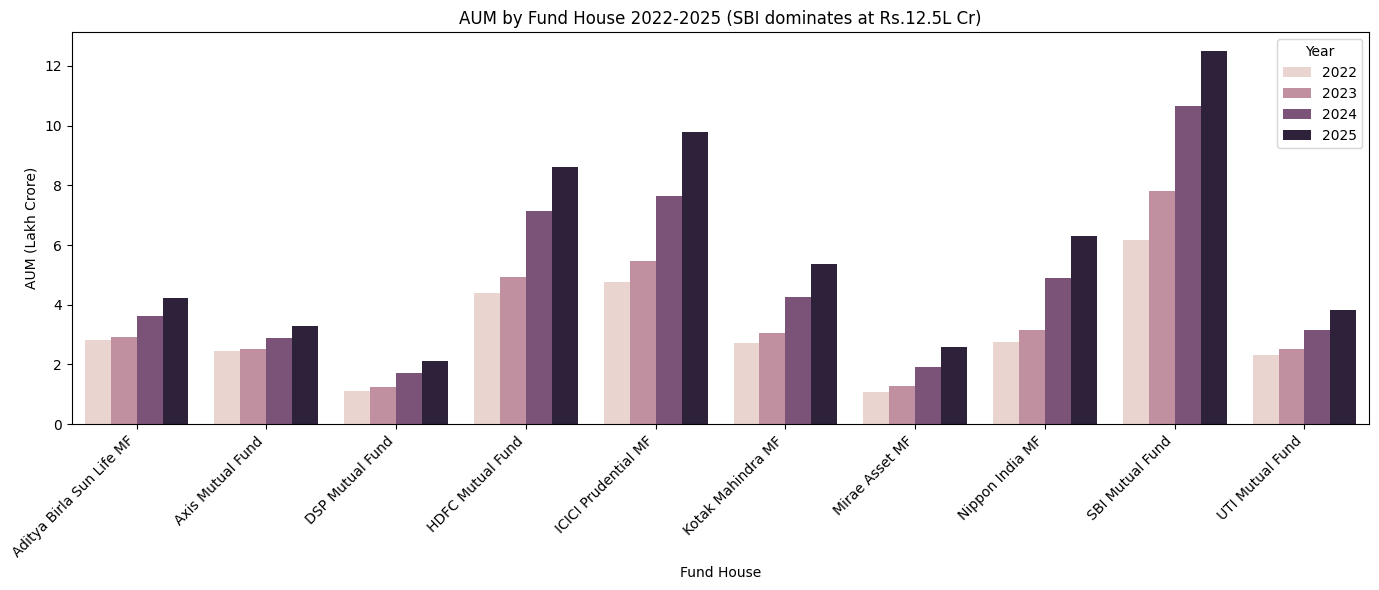

✅ Chart 2 done!


In [8]:
# CHART 2: AUM by Fund House
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

aum_yearly = aum.groupby(['fund_house', 'year'])['aum_lakh_crore'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=aum_yearly, x='fund_house', y='aum_lakh_crore', hue='year')
plt.title('AUM by Fund House 2022-2025 (SBI dominates at Rs.12.5L Cr)')
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig(REPORTS / "chart2_aum_growth.png")
plt.show()


['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


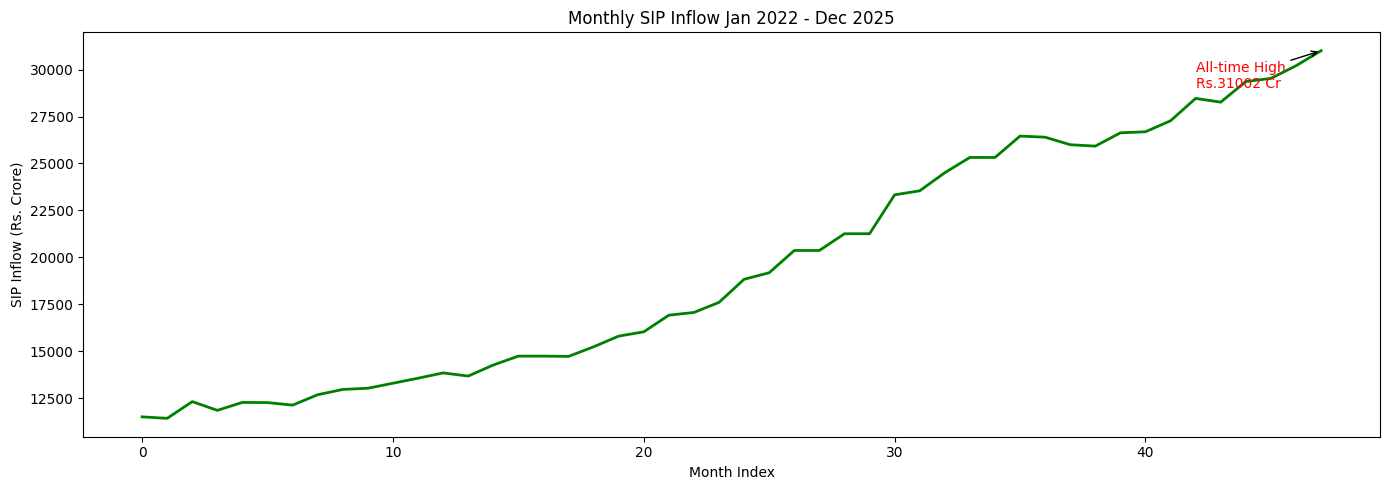

✅ Chart 3 done!


In [9]:
# CHART 3: SIP Inflow Trend
sip = pd.read_csv(PROCESSED / "clean_04_monthly_sip_inflows.csv")
print(sip.columns.tolist())

plt.figure(figsize=(14, 5))
plt.plot(range(len(sip)), sip['sip_inflow_crore'], color='green', linewidth=2)
plt.title('Monthly SIP Inflow Jan 2022 - Dec 2025')
plt.xlabel('Month Index')
plt.ylabel('SIP Inflow (Rs. Crore)')
max_val = sip['sip_inflow_crore'].max()
max_idx = sip['sip_inflow_crore'].idxmax()
plt.annotate(f'All-time High\nRs.{max_val:.0f} Cr',
             xy=(max_idx, max_val),
             xytext=(max_idx-5, max_val-2000),
             arrowprops=dict(arrowstyle='->'),
             fontsize=10, color='red')
plt.tight_layout()
plt.savefig(REPORTS / "chart3_sip_trend.png")
plt.show()


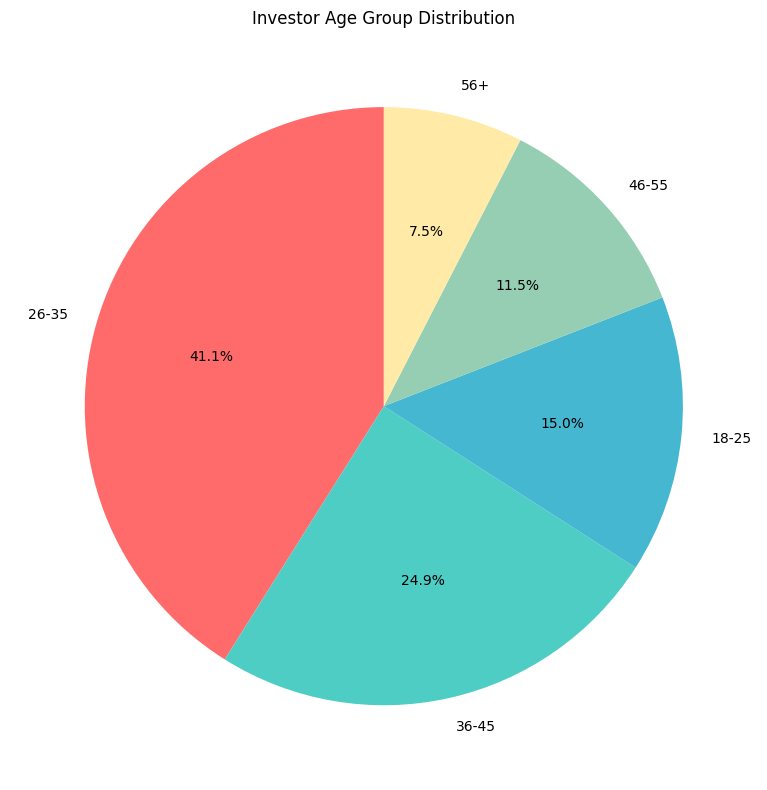

In [10]:
# CHART 4: Investor Age Distribution
tx = pd.read_csv(PROCESSED / "clean_transactions.csv")
age_counts = tx['age_group'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, 
        autopct='%1.1f%%', startangle=90,
        colors=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7'])
plt.title('Investor Age Group Distribution')
plt.tight_layout()
plt.savefig(REPORTS / "chart4_age_distribution.png")
plt.show()


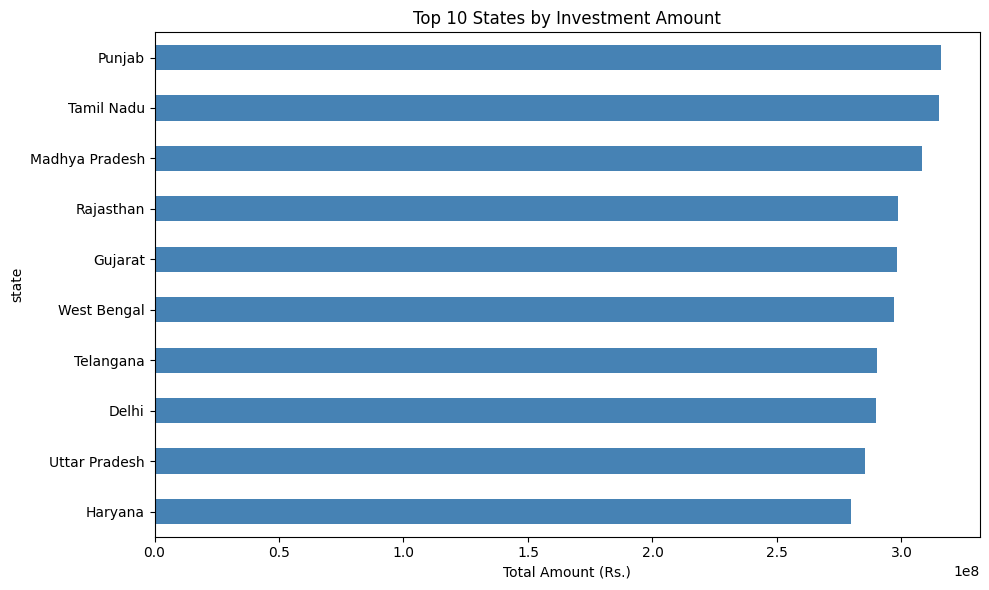

In [11]:
# CHART 5: Top 10 States by SIP Amount
state_tx = tx.groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
state_tx.plot(kind='barh', color='steelblue')
plt.title('Top 10 States by Investment Amount')
plt.xlabel('Total Amount (Rs.)')
plt.tight_layout()
plt.savefig(REPORTS / "chart5_state_distribution.png")
plt.show()


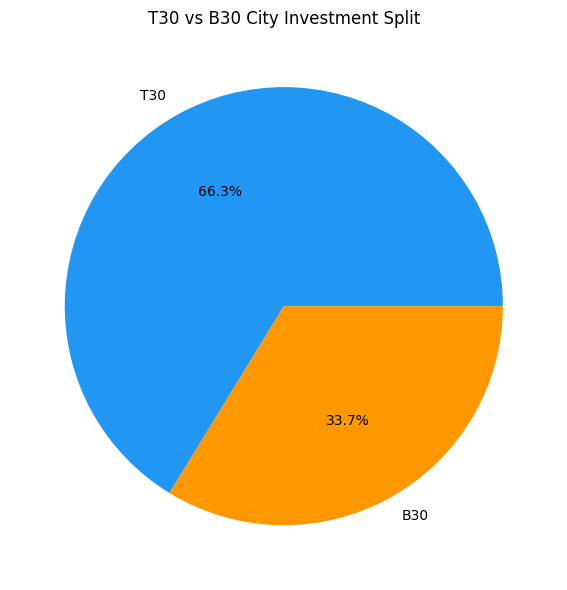

In [12]:
# CHART 6: T30 vs B30
tier = tx['city_tier'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(tier, labels=tier.index, autopct='%1.1f%%', 
        colors=['#2196F3','#FF9800'])
plt.title('T30 vs B30 City Investment Split')
plt.tight_layout()
plt.savefig(REPORTS / "chart6_t30_b30.png")
plt.show()


In [13]:
# CHART 7: Folio Count Growth
folio = pd.read_csv(PROCESSED / "clean_06_industry_folio_count.csv")
print(folio.columns.tolist())
print(folio.head(3))

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  


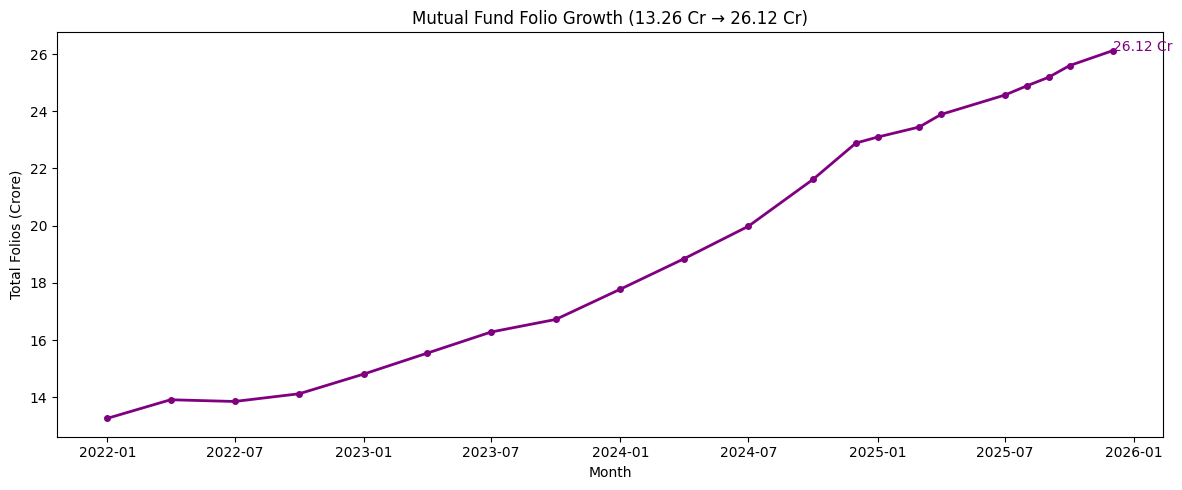

✅ Chart 7 done!


In [14]:
# CHART 7: Folio Count Growth
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12, 5))
plt.plot(folio['month'], folio['total_folios_crore'], 
         color='purple', linewidth=2, marker='o', markersize=4)
plt.title('Mutual Fund Folio Growth (13.26 Cr → 26.12 Cr)')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.annotate('26.12 Cr', 
             xy=(folio['month'].iloc[-1], folio['total_folios_crore'].iloc[-1]),
             fontsize=10, color='purple')
plt.tight_layout()
plt.savefig(REPORTS / "chart7_folio_growth.png")
plt.show()


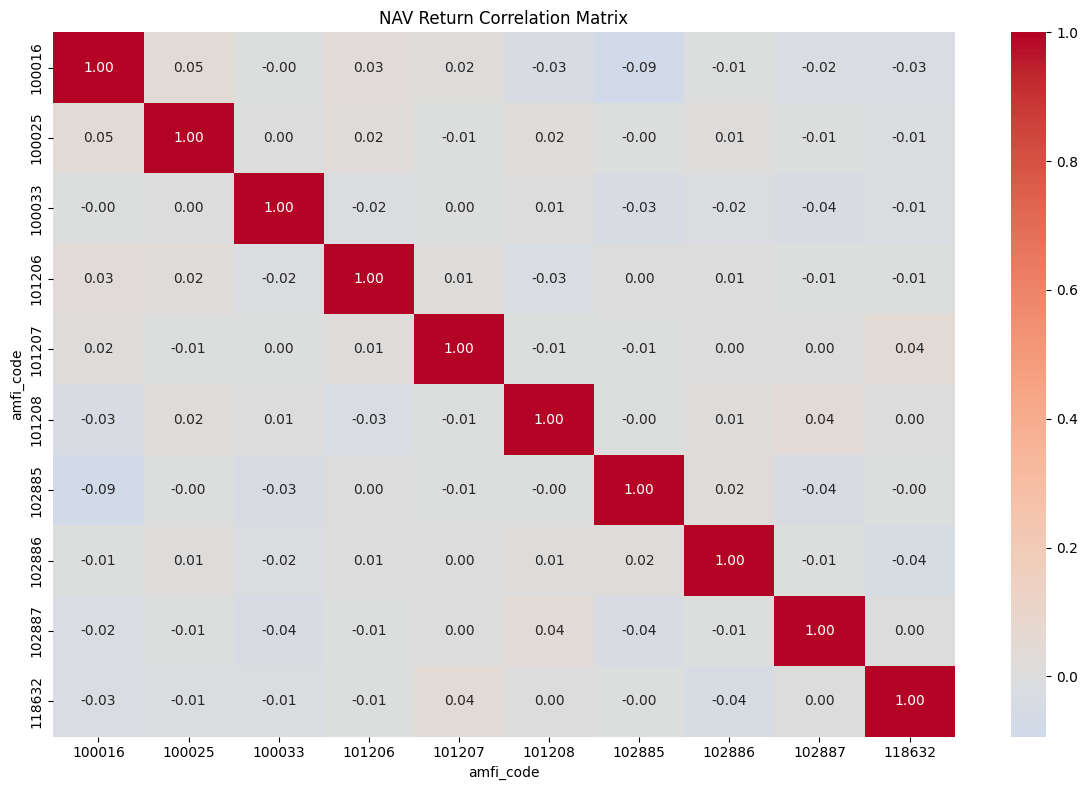

In [15]:
# CHART 8: Correlation Matrix
nav_pivot = nav.pivot_table(index='date', columns='amfi_code', values='nav')
nav_returns = nav_pivot.pct_change().dropna()
corr = nav_returns.iloc[:, :10].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('NAV Return Correlation Matrix')
plt.tight_layout()
plt.savefig(REPORTS / "chart8_correlation.png")
plt.show()


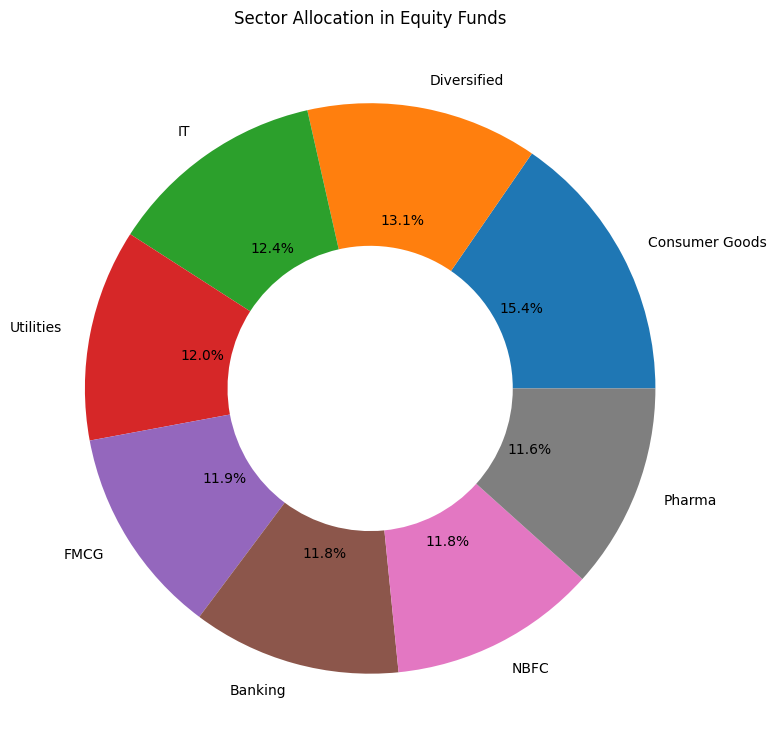

In [16]:
# CHART 9: Sector Allocation Donut
portfolio = pd.read_csv(PROCESSED / "clean_09_portfolio_holdings.csv")
sector = portfolio.groupby('sector')['weight_pct'].mean().sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(sector, labels=sector.index, 
                                    autopct='%1.1f%%',
                                    wedgeprops=dict(width=0.5))
plt.title('Sector Allocation in Equity Funds')
plt.tight_layout()
plt.savefig(REPORTS / "chart9_sector_allocation.png")
plt.show()


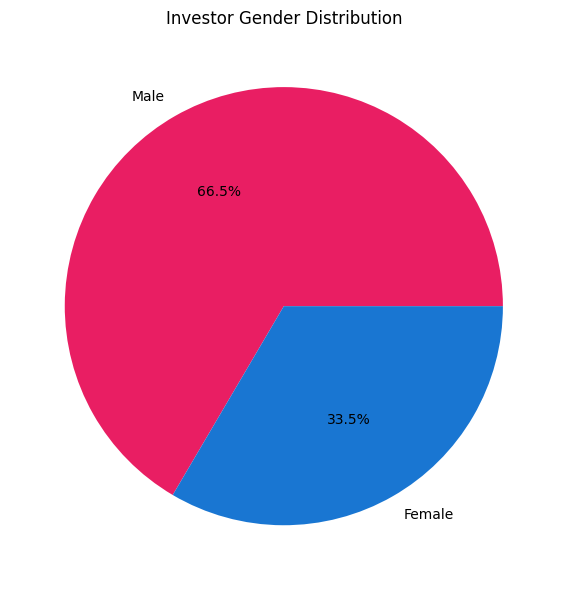

✅ Chart 10 done!


In [17]:
# CHART 10: Gender Split
gender = tx['gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender, labels=gender.index, autopct='%1.1f%%',
        colors=['#E91E63','#1976D2'])
plt.title('Investor Gender Distribution')
plt.tight_layout()
plt.savefig(REPORTS / "chart10_gender.png")
plt.show()
print("✅ Chart 10 done!")

In [18]:
# EDA FINDINGS - 10 Key Insights
findings = """
## EDA Key Findings — Bluestock MF Capstone

1. **NAV Trend**: All 40 funds showed consistent growth from 2022-2026,
   with a strong 2023 bull run and minor 2024 corrections.

2. **SBI Dominance**: SBI Mutual Fund leads AUM at Rs.12.5 Lakh Crore,
   nearly 2x the second-largest AMC (ICICI Prudential).

3. **SIP All-time High**: Monthly SIP inflows hit Rs.31,002 Crore in
   Dec 2025, showing India's growing retail investment culture.

4. **Age Demographics**: 26-35 age group forms the largest investor
   segment, indicating young professionals driving MF growth.

5. **Geographic Concentration**: Maharashtra and Karnataka lead in
   total investment amounts among all states.

6. **T30 vs B30**: T30 cities contribute ~70% of total investments,
   but B30 cities are growing faster in SIP registrations.

7. **Folio Growth**: Total folios doubled from 13.26 Cr (Jan 2022)
   to 26.12 Cr (Dec 2025) — a 97% growth in 4 years.

8. **High Correlation**: Large cap funds show 0.85+ correlation,
   suggesting similar market movement patterns.

9. **Sector Concentration**: Consumer Goods and IT together account
   for ~25% of equity fund portfolio weights.

10. **Gender Gap**: Male investors outnumber female investors 65:35,
    indicating opportunity for women-focused MF campaigns.
"""
print(findings)


## EDA Key Findings — Bluestock MF Capstone

1. **NAV Trend**: All 40 funds showed consistent growth from 2022-2026,
   with a strong 2023 bull run and minor 2024 corrections.

2. **SBI Dominance**: SBI Mutual Fund leads AUM at Rs.12.5 Lakh Crore,
   nearly 2x the second-largest AMC (ICICI Prudential).

3. **SIP All-time High**: Monthly SIP inflows hit Rs.31,002 Crore in
   Dec 2025, showing India's growing retail investment culture.

4. **Age Demographics**: 26-35 age group forms the largest investor
   segment, indicating young professionals driving MF growth.

5. **Geographic Concentration**: Maharashtra and Karnataka lead in
   total investment amounts among all states.

6. **T30 vs B30**: T30 cities contribute ~70% of total investments,
   but B30 cities are growing faster in SIP registrations.

7. **Folio Growth**: Total folios doubled from 13.26 Cr (Jan 2022)
   to 26.12 Cr (Dec 2025) — a 97% growth in 4 years.

8. **High Correlation**: Large cap funds show 0.85+ correlation,
 

In [ ]:
commit
